# 🔭 Modelo: de radiancia satelital a Bortle

**StarMap BA · análisis de datos** — por Joaquín Rao

En el [notebook 01](01_contaminacion_luminica_ba.ipynb) *validé* que el Bortle que
asigné a mano correlaciona con la radiancia del satélite (Spearman **+0.76**). Acá
voy un paso más: **¿puedo predecir el Bortle de un lugar a partir de la radiancia
VIIRS?**

> ⚠️ **Honestidad primero:** tengo solo **21 puntos etiquetados**. Para machine
> learning eso es muy poco. Así que el objetivo no es un modelo grande, sino uno
> **simple, interpretable y validado** (leave-one-out). Es una *calibración*
> radiancia→Bortle, no un oráculo.

In [1]:
%matplotlib inline
from pathlib import Path
import json, re
import numpy as np
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

DATA = Path("data")
plt.rcParams.update({"figure.dpi": 110})

## 1. Datos: Bortle (a mano) vs radiancia (satélite)

Para cada uno de los 21 puntos tomo su Bortle asignado y la **radiancia media en
3 km** alrededor (la misma medida que mejor correlacionó en el notebook 01).

In [2]:
pts = json.loads(Path("../data/seed-points.json").read_text("utf-8"))["puntos"]
with rasterio.open(DATA / "viirs_ba_2024.tif") as ds:
    arr = ds.read(1).astype("float64")
    bounds, transform = ds.bounds, ds.transform
    deg = 3 / 111.0  # ~3 km en grados

    def rad3km(lat, lng):
        r0, c0 = ds.index(lng - deg, lat + deg)
        r1, c1 = ds.index(lng + deg, lat - deg)
        (r0, r1), (c0, c1) = sorted((r0, r1)), sorted((c0, c1))
        w = arr[max(0, r0):r1 + 1, max(0, c0):c1 + 1]
        return float(w.mean()) if w.size else np.nan

bortle = np.array([p["bortle"] for p in pts], dtype="float64")
rad = np.array([rad3km(p["lat"], p["lng"]) for p in pts])
x = np.log10(rad + 0.1)  # log: la escala Bortle es logarítmica en brillo
print(f"{len(pts)} puntos | Bortle {bortle.min():.0f}-{bortle.max():.0f} "
      f"| radiancia 3km {rad.min():.2f}-{rad.max():.1f} nW/cm²/sr")

21 puntos | Bortle 2-8 | radiancia 3km 0.00-75.7 nW/cm²/sr


## 2. El modelo

La escala Bortle es aproximadamente **logarítmica** en el brillo del cielo, así
que ajusto una recta `Bortle ≈ a + b · log10(radiancia)`. Un solo parámetro de
pendiente: imposible de sobreajustar, fácil de explicar.

In [3]:
fit = np.polyfit(x, bortle, 1)            # [pendiente, intercepto]
pred = np.polyval(fit, x)
ss_res = ((bortle - pred) ** 2).sum()
ss_tot = ((bortle - bortle.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"Bortle ≈ {fit[0]:.2f} · log10(radiancia) + {fit[1]:.2f}")
print(f"R² (in-sample) = {r2:.2f}")

Bortle ≈ 1.54 · log10(radiancia) + 4.63
R² (in-sample) = 0.70


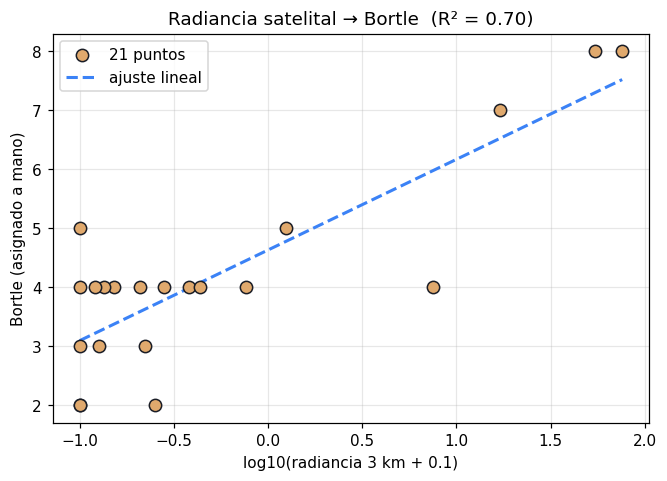

In [4]:
xs = np.linspace(x.min(), x.max(), 100)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(x, bortle, s=65, color="#e0a96d", edgecolor="#1a1d26", zorder=3, label="21 puntos")
ax.plot(xs, np.polyval(fit, xs), "--", color="#3b82f6", lw=2, label="ajuste lineal")
ax.set(xlabel="log10(radiancia 3 km + 0.1)", ylabel="Bortle (asignado a mano)",
       title=f"Radiancia satelital → Bortle  (R² = {r2:.2f})")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. ¿Cuánto le creo? — Validación leave-one-out

Con 21 puntos, la validación honesta es **leave-one-out**: saco un punto, entreno
con los otros 20, predigo el que saqué, y repito 21 veces. Así mido el error en
datos que el modelo **no vio**.

In [5]:
n = len(bortle)
loo = np.empty(n)
for i in range(n):
    m = np.arange(n) != i
    f = np.polyfit(x[m], bortle[m], 1)
    loo[i] = np.polyval(f, x[i])

mae = np.abs(loo - bortle).mean()
within1 = (np.abs(np.round(loo) - bortle) <= 1).mean()
print(f"Leave-one-out CV (n={n}):")
print(f"  Error absoluto medio (MAE): {mae:.2f} clases Bortle")
print(f"  Aciertos dentro de ±1 clase: {100 * within1:.0f}% de los puntos")

Leave-one-out CV (n=21):
  Error absoluto medio (MAE): 0.79 clases Bortle
  Aciertos dentro de ±1 clase: 86% de los puntos


## 4. El modelo aplicado: un mapa de Bortle desde el satélite

Si aplico la recta a **cada celda** del ráster, obtengo un mapa continuo de Bortle
estimado para toda la Provincia — derivado del satélite, no asignado a mano.

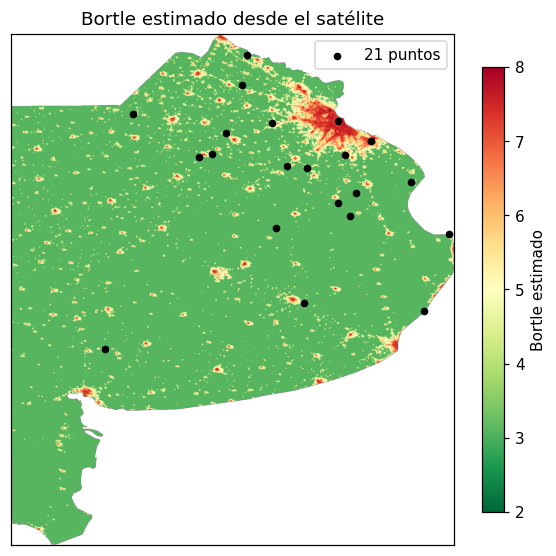

In [6]:
ring = json.loads(
    re.search(r"\[\[.*\]\]", Path("../lib/ba-province.ts").read_text("utf-8"),
              re.DOTALL).group(0)
)
ba = geometry_mask([{"type": "Polygon", "coordinates": [ring]}],
                   out_shape=arr.shape, transform=transform, invert=True)

bmap = np.clip(np.polyval(fit, np.log10(arr + 0.1)), 1, 9)
bmap = np.where(ba, bmap, np.nan)

ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]
fig, ax = plt.subplots(figsize=(6.5, 7.5))
im = ax.imshow(bmap, extent=ext, origin="upper", cmap="RdYlGn_r", vmin=2, vmax=8)
ax.scatter([p["lng"] for p in pts], [p["lat"] for p in pts],
           s=16, c="black", zorder=3, label="21 puntos")
ax.set(title="Bortle estimado desde el satélite", xticks=[], yticks=[])
plt.colorbar(im, ax=ax, label="Bortle estimado", shrink=0.7)
ax.legend(loc="upper right")
plt.show()

## Conclusiones

- Una **recta sobre el log de la radiancia** ya predice el Bortle razonablemente
  bien — coherente con que la escala Bortle es logarítmica en brillo.
- La validación **leave-one-out** (el número honesto, no el R² in-sample) dice
  cuánto le podemos creer en lugares nuevos.
- Aplicado a la grilla, da un **mapa de Bortle continuo derivado del satélite**:
  pasa de 21 etiquetas a mano a una estimación para toda la Provincia.

### Limitaciones (lo honesto)

- **n = 21** es chico: el modelo es a propósito simple (una recta) para no
  sobreajustar. No es deep learning ni pretende serlo.
- Las etiquetas Bortle son **mías**, no un ground-truth independiente. El modelo
  aprende a reproducir mi criterio (que sí está validado contra el satélite).
- **Próximo paso (camino B):** sumar etiquetas públicas (Globe at Night, SQM,
  lightpollutionmap) para llegar a cientos de puntos y entrenar algo más rico
  (isotónica, gradient boosting) con train/test de verdad.

*Dato: VIIRS VNL 2024 (EOG/NOAA, dominio público). Polígono de BA: IGN. Análisis: Joaquín Rao.*